In [1]:
from textwrap import wrap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('olist_cleaned.csv')

In [3]:
def format_labels(labels, short=False):
    """Replaces _ with space and sets maximum char length"""
    result = []
    for label in labels:
        spaced = " ".join(label.split("_"))
        if len(spaced)>20 and short == True:
            result.append(spaced[:18]+"...")
        else:
            result.append("\n".join(wrap(spaced,20)))
    return result

# Target Variable: Review Score and High/Low class

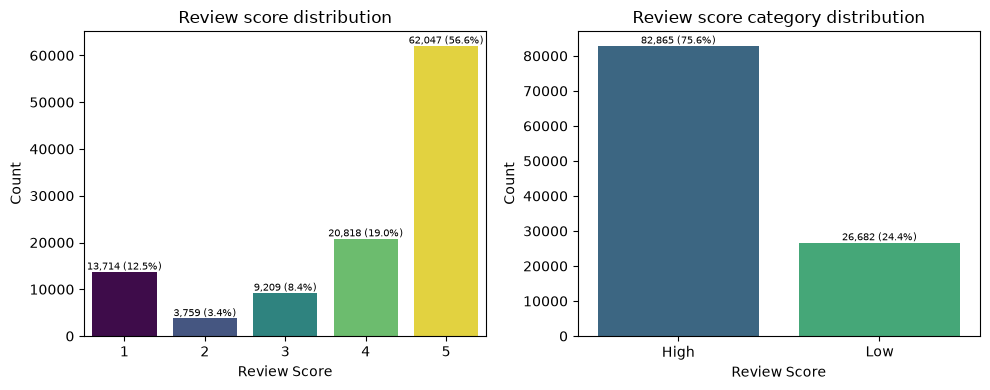

In [4]:
fig, axes = plt.subplots(1,2,figsize=(10,4),sharex=False)

def plot_review_score(column, ax):
    sns.countplot(
        data=df, 
        x=column, 
        order=sorted(df[column].unique()),  
        legend=None, 
        ax=axes[ax],
        hue=column,
        palette='viridis'
        )

    score_values = df[column].value_counts().sort_index()
    score_percentages = (score_values/score_values.sum())*100
    for patch, count, percentage in zip(
        [patch for patch in axes[ax].patches if patch.get_height() > 0],
        score_values,
        score_percentages
    ):
        axes[ax].annotate(
            f"{count:,} ({percentage:.1f}%)",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            fontsize=7
        )

plot_review_score('review_score',0)

order = sorted(df["review_score"].unique())

axes[0].set_xticks(ticks=range(len(order)), labels=[1,2,3,4,5])
axes[0].set_xticklabels([str(int(score)) for score in order])

axes[0].set_title('Review score distribution')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

plot_review_score('score_class',1)

axes[1].set_title('Review score category distribution')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Numerical Feature: Review Score

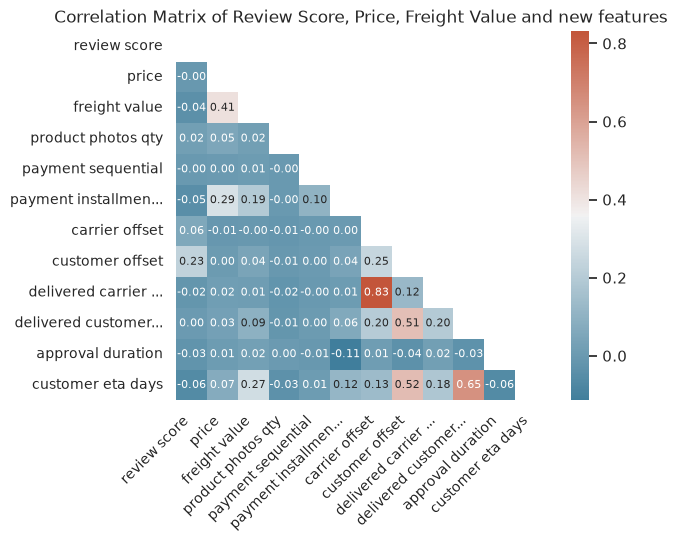

In [5]:
# Correlation matrix of select numerical features
df_reduced = df[['review_score','price','freight_value','product_photos_qty',
                       'payment_sequential','payment_installments_total',
                       'carrier_offset', 'customer_offset', 
                       'delivered_carrier_days', 'delivered_customer_days',
                       'approval_duration', 'customer_eta_days']]
corr = df_reduced.corr()
label = format_labels(list(df_reduced.columns),short=True)

sns.set_theme(style="white")
cmap = sns.diverging_palette(230, 20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, cmap=cmap, annot=True, fmt=".2f",mask=mask, square = True, annot_kws={'size': 8}, xticklabels=label, yticklabels=label)
plt.tick_params(axis='both', labelsize=10)
plt.yticks(va='center', rotation_mode='anchor')
plt.xticks(ha='right', rotation_mode='xtick', va='top', rotation=45)
plt.title('Correlation Matrix of Review Score, Price, Freight Value and new features')
plt.show()

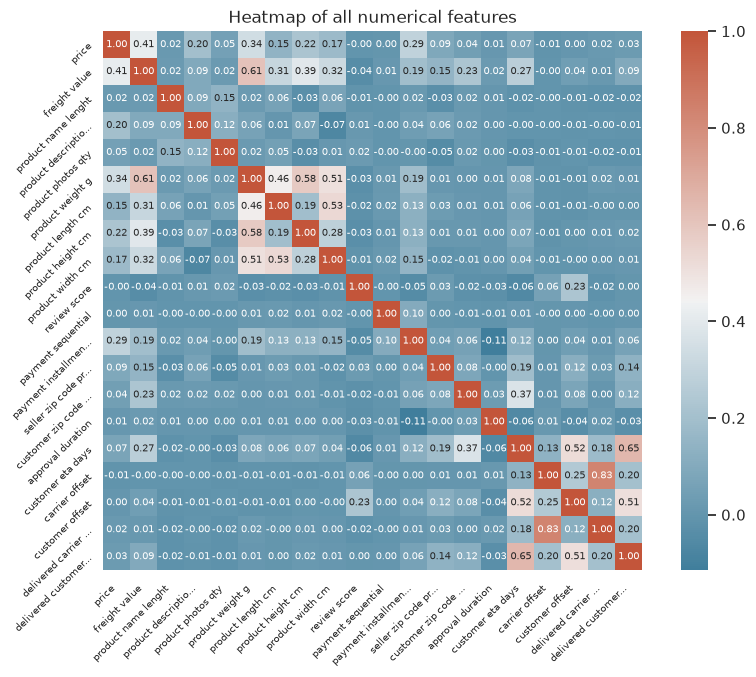

In [6]:
# Correlation matrix of all numerical features
corr = df.select_dtypes(include=[int, float, np.number]).corr()
label = format_labels(list(df.select_dtypes(include=[int, float, np.number]).columns),short=True)

sns.set_theme(style="white")
cmap = sns.diverging_palette(230, 20, as_cmap=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap=cmap, annot=True, fmt=".2f", square = True, annot_kws={'size': 7}, xticklabels=label, yticklabels=label)
plt.tick_params(axis='both', labelsize=7)
plt.yticks(va='center', rotation_mode='anchor', rotation=45)
plt.xticks(ha='left', rotation_mode='xtick', rotation=45)
plt.title('Heatmap of all numerical features')
plt.show()

In [7]:
categorical_cols = [
    "delivered_carrier",
    "delivered_customer",
    "seller_state",
    "customer_state",
    "order_status",
    "payment_type_all",
    "product_category_name_english",
]

mean_score_ranking = (
    df.groupby(categorical_cols, dropna=False)["review_score"]
      .mean()
)


In [8]:
mean_score_summary = []

for col in categorical_cols:
    grouped = (
        df.groupby(col, dropna=False)["review_score"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={
            col: "category",
            "mean": "mean_score"
        })
    )
    grouped["feature"] = col
    mean_score_summary.append(grouped)

mean_score_summary = pd.concat(mean_score_summary, ignore_index=True)

mean_score_summary.sort_values(
    "mean_score",
    ascending=False
).head(20)

,category,mean_score,count,feature
81,cds_dvds_musicals,4.642857,14,product_category_name_english
19,PA,4.500000,8,seller_state
99,fashion_childrens_clothes,4.500000,8,product_category_name_english
17,MS,4.469388,49,seller_state
78,books_general_interest,4.446266,549,product_category_name_english
92,costruction_tools_tools,4.444444,99,product_category_name_english
105,flowers,4.419355,31,product_category_name_english
79,books_imported,4.400000,60,product_category_name_english
80,books_technical,4.361217,263,product_category_name_english
123,luggage_accessories,4.313996,1086,product_category_name_english


## Review score-Customer offset Boxplot

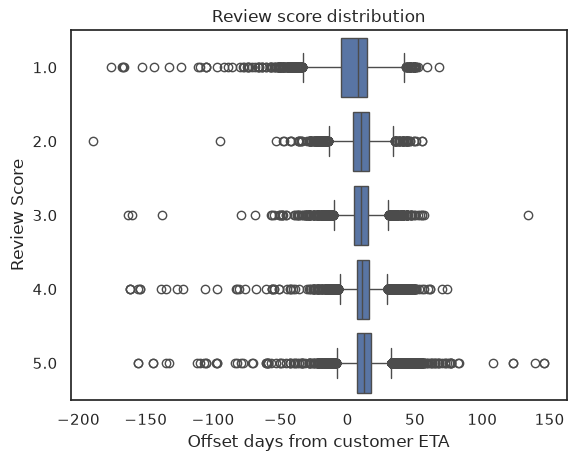

In [9]:
sns.boxplot(data=df, x='customer_offset', y='review_score', orient='y',legend=None)
plt.title('Review score distribution')
plt.ylabel('Review Score')
plt.xlabel('Offset days from customer ETA')
plt.show()

## Payment Methods by Ave Score

/tmp/ipykernel_62277/3489761331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


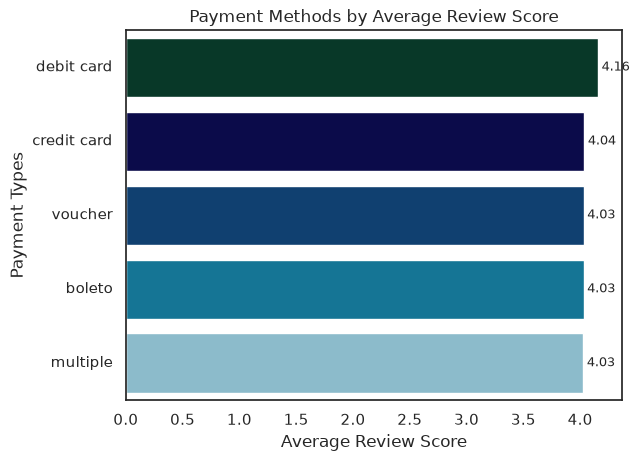

In [10]:
payment_type_score = df.groupby('payment_type_all')['review_score'].mean().nlargest(10)
labels = list(payment_type_score.index)

fig, ax = plt.subplots()

ax = sns.barplot(
    x=payment_type_score.values,
    y=payment_type_score.index,
    orient='h',
    palette='ocean',
    legend=False
)


for bar, mean in zip(ax.patches, payment_type_score.values):
    ax.text(
        mean + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.title('Payment Methods by Average Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Payment Types')
plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')
plt.show()


## Product Categories by Ave Score

/tmp/ipykernel_62277/2903823041.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_score_big,orient='h', palette='ocean',ax=axes[0])
/tmp/ipykernel_62277/2903823041.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_score_small,orient='h', palette='ocean_r',ax=axes[1])


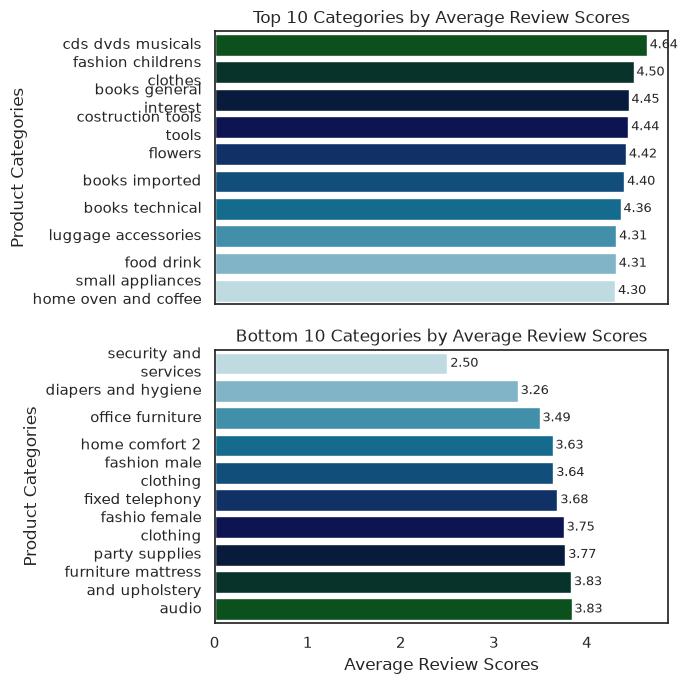

In [11]:
cat_score_big = df.groupby('product_category_name_english')['review_score'].mean().nlargest(10)
labels = list(cat_score_big.index)

fig, axes = plt.subplots(2,1,figsize=(7,7),sharex=True)

ax = sns.barplot(data=cat_score_big,orient='h', palette='ocean',ax=axes[0])

for bar, mean in zip(ax.patches, cat_score_big.values):
    ax.text(
        mean + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9
    )

axes[0].set_title('Top 10 Categories by Average Review Scores')
axes[0].set_xlabel('Average Review Scores')
axes[0].set_ylabel('Product Categories')
axes[0].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

cat_score_small = df.groupby('product_category_name_english')['review_score'].mean().nsmallest(10)
labels = list(cat_score_small.index)

ax = sns.barplot(data=cat_score_small,orient='h', palette='ocean_r',ax=axes[1])

for bar, mean in zip(ax.patches, cat_score_small.values):
    ax.text(
        mean + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9
    )

axes[1].set_title('Bottom 10 Categories by Average Review Scores')
axes[1].set_xlabel('Average Review Scores')
axes[1].set_ylabel('Product Categories')
axes[1].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

plt.tight_layout()
plt.show()

## State by Ave Score

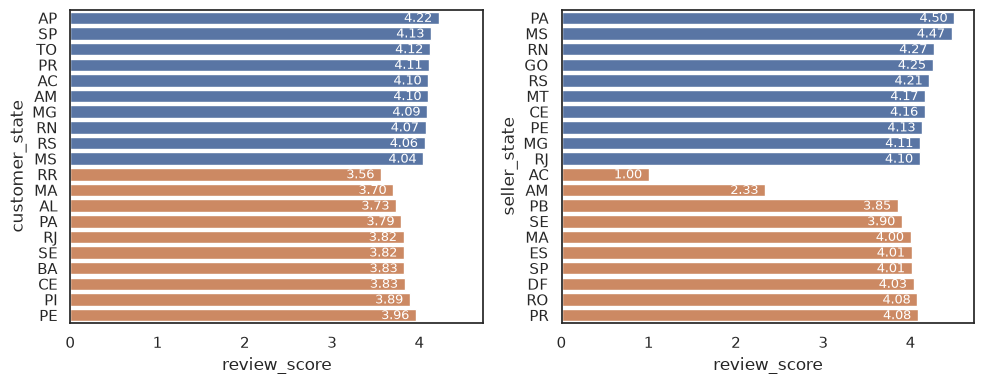

In [12]:
top10_cust_state_score = df.groupby('customer_state')['review_score'].mean().nlargest(10)
bot10_cust_state_score = df.groupby('customer_state')['review_score'].mean().nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = sns.barplot(data=top10_cust_state_score,orient='h',ax=axes[0])
# axes[0].set_title('Top 10 States by Average Review Scores (Customer)')
# axes[0].set_xlabel('Review Score')
# axes[0].set_ylabel('Customer State')
for bar, mean in zip(ax.patches, top10_cust_state_score.values):
    ax.text(
        mean-0.4,
        (bar.get_y() + bar.get_height() / 2)+0.05,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9,
        color='white'
    )
ax = sns.barplot(data=bot10_cust_state_score,orient='h',ax=axes[0])
for bar, mean in zip(ax.patches, bot10_cust_state_score.values):
    ax.text(
        mean-0.4,
        10.05+(bar.get_y() + bar.get_height() / 2),
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9,
        color='white'
    )
# axes[0].set_title('Top 10 States by Average Review Scores (Customer)')
# axes[0].set_xlabel('Review Score')
# axes[0].set_ylabel('Customer State')

top10_seller_state_score = df.groupby('seller_state')['review_score'].mean().nlargest(10)
bot10_seller_state_score = df.groupby('seller_state')['review_score'].mean().nsmallest(10)

ax = sns.barplot(data=top10_seller_state_score,orient='h',ax=axes[1])
for bar, mean in zip(ax.patches, top10_seller_state_score.values):
    ax.text(
        mean-0.4,
        (bar.get_y() + bar.get_height() / 2)+0.05,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9,
        color='white'
    )
# axes[1].set_title('Top 10 States by Average Review Scores (Seller)')
# axes[1].set_xlabel('Review Score')
# axes[1].set_ylabel('Seller State')
ax = sns.barplot(data=bot10_seller_state_score,orient='h',ax=axes[1])
for bar, mean in zip(ax.patches, bot10_seller_state_score.values):
    ax.text(
        mean-0.4,
        10.05+(bar.get_y() + bar.get_height() / 2),
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9,
        color='w'
    )
# axes[1].set_title('Top 10 States by Average Review Scores (Seller)')
# axes[1].set_xlabel('Review Score')
# axes[1].set_ylabel('Seller State')

plt.tight_layout()
plt.show()

## Order status by Ave review score

/tmp/ipykernel_62277/2473558118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=order_status_score,orient='h', palette='viridis')


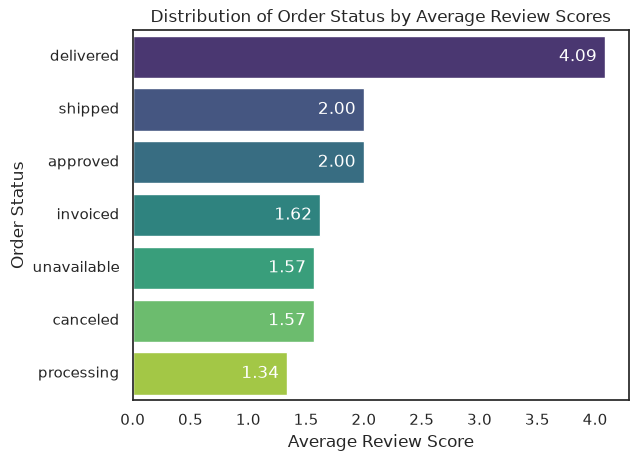

In [13]:
order_status_score = df.groupby('order_status')['review_score'].mean().nlargest(10)
labels = list(order_status_score.index)

ax = sns.barplot(data=order_status_score,orient='h', palette='viridis')
for bar, mean in zip(ax.patches, order_status_score.values):
    ax.text(
        mean-0.4,
        bar.get_y() + bar.get_height() / 2,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=12,
        color="white"
    )
plt.title('Distribution of Order Status by Average Review Scores')
plt.xlabel('Average Review Score')
plt.ylabel('Order Status')
plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

plt.show()

## Delivery status by ave review score

/tmp/ipykernel_62277/4232323333.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=carr_score,orient='h', palette='ocean',ax=axes[0])
/tmp/ipykernel_62277/4232323333.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cust_score,orient='h', palette='ocean',ax=axes[1])


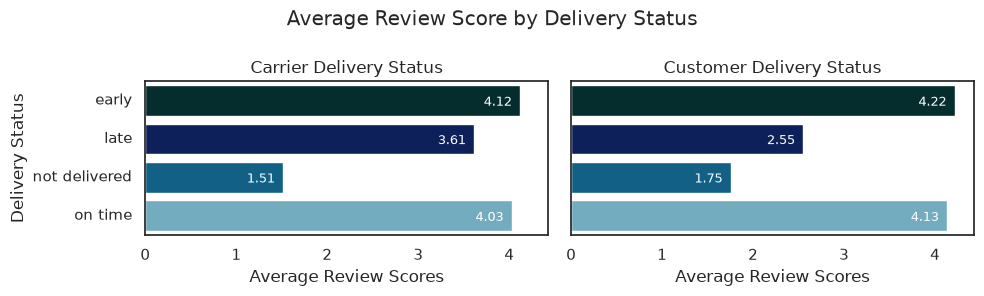

In [14]:
carr_score = df.groupby("delivered_carrier")['review_score'].mean()
labels = list(carr_score.index)

fig, axes = plt.subplots(1,2,figsize=(10,3),sharex=True, sharey=True)

ax = sns.barplot(data=carr_score,orient='h', palette='ocean',ax=axes[0])
for bar, mean in zip(ax.patches, carr_score.values):
    ax.text(
        mean-0.4,
        (bar.get_y() + bar.get_height() / 2)+0.05,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9,
        color='white'
    )
axes[0].set_title('Carrier Delivery Status')
axes[0].set_xlabel('Average Review Scores')
axes[0].set_ylabel('Delivery Status')
axes[0].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

cust_score = df.groupby("delivered_customer")['review_score'].mean()
labels = list(cust_score.index)

ax = sns.barplot(data=cust_score,orient='h', palette='ocean',ax=axes[1])
for bar, mean in zip(ax.patches, cust_score.values):
    ax.text(
        mean-0.4,
        (bar.get_y() + bar.get_height() / 2)+0.05,
        f'{mean:.2f}',
        va='center',
        ha='left',
        fontsize=9,
        color='white'
    )
axes[1].set_title('Customer Delivery Status')
axes[1].set_xlabel('Average Review Scores')
axes[1].set_ylabel('Delivery Status')
axes[1].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

plt.suptitle("Average Review Score by Delivery Status")
plt.tight_layout()
plt.show()

## Proportion of empty review comments by average review score

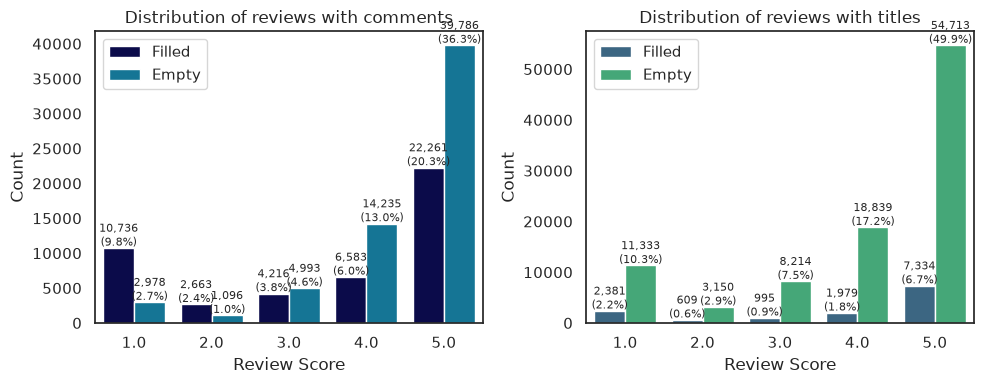

In [15]:
empty_reviews = pd.concat(
    [df['review_score'],
     df['review_comment_message'].isna().rename("empty_comment"),
     df['review_comment_title'].isna().rename("empty_title")],
     axis=1
)
label = ['Filled', 'Empty']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = sns.countplot(
    data=empty_reviews,
    x='review_score',
    hue='empty_comment',
    palette='ocean',
    ax=axes[0]
 )
empty_values = empty_reviews['empty_comment'].value_counts().sort_index()
empty_percentages = (empty_values/empty_values.sum())*100
for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:
        percentage = count / len(empty_reviews) * 100
        ax.annotate(
            f'{count:,}\n({percentage:.1f}%)',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center',
            va='bottom',
            xytext=(0, -1),
            textcoords='offset points',
            fontsize=8
        )
axes[0].legend(labels=label)
axes[0].set_title('Distribution of reviews with comments')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

ax = sns.countplot(
    data=empty_reviews,
    x='review_score',
    hue='empty_title',
    palette='viridis',
    ax=axes[1]
 )

empty_values = empty_reviews['empty_title'].value_counts().sort_index()
empty_percentages = (empty_values/empty_values.sum())*100
for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:
        percentage = count / len(empty_reviews) * 100
        ax.annotate(
            f'{count:,}\n({percentage:.1f}%)',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center',
            va='bottom',
            xytext=(0, -1),
            textcoords='offset points',
            fontsize=8
        )
axes[1].legend(labels=label)
axes[1].set_title('Distribution of reviews with titles')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Categorical Feature: Review Score Category

## Proportion of empty comment and title against High/Low

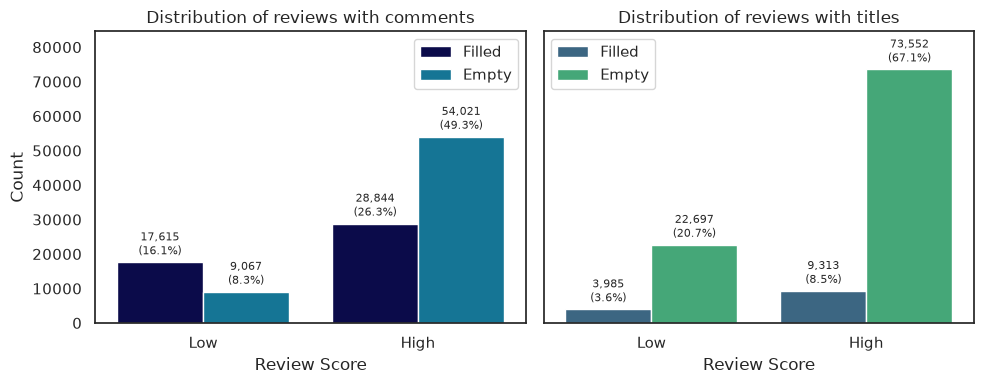

In [16]:
empty_reviews_cat = pd.concat(
    [df['score_class'],
     df['review_comment_message'].isna().rename("empty_comment"),
     df['review_comment_title'].isna().rename("empty_title")],
     axis=1
)
score_class_order = ["Low","High"]
label = ['Filled', 'Empty']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.countplot(
    data=empty_reviews_cat,
    x='score_class',
    order=score_class_order,
    hue='empty_comment',
    palette='ocean',
    ax=axes[0]
 )
for bar in axes[0].patches:
    count = int(bar.get_height())
    if count > 0:
        percentage = count / len(empty_reviews_cat) * 100
        axes[0].annotate(
            f'{count:,}\n({percentage:.1f}%)',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8
        )
axes[0].legend(labels=label)
axes[0].set_title('Distribution of reviews with comments')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

sns.countplot(
    data=empty_reviews_cat,
    x='score_class',
    order=score_class_order,
    hue='empty_title',
    palette='viridis',
    ax=axes[1]
 )
for bar in axes[1].patches:
    count = int(bar.get_height())
    if count > 0:
        percentage = count / len(empty_reviews_cat) * 100
        axes[1].annotate(
            f'{count:,}\n({percentage:.1f}%)',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8
        )
axes[1].legend(labels=label)
axes[1].set_title('Distribution of reviews with titles')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

max_count = max(
    bar.get_height()
    for axis in axes
    for bar in axis.patches
 )
axes[0].set_ylim(0, max_count * 1.15)

plt.tight_layout()
plt.show()

In [17]:
def plot_categorical_against_score(col, ax):
    """Helper function to plot categorical columns against score class"""
    top_categories = df[col].value_counts().head(10).index

    proportions = pd.crosstab(
        df[col],
        df["score_class"],
        normalize="index"
    ).loc[top_categories]
    

    counts = pd.crosstab(
        df[col],
        df["score_class"]
    ).reindex(
        index=proportions.index,
        columns=proportions.columns,
        fill_value=0
    )
        
    axes[ax] = proportions.plot(
        kind="bar",
        stacked=True,
        colormap="Set2",
        ax=axes[ax],
        legend=None
    )

    for container, category in zip(axes[ax].containers, proportions.columns):
        for patch, percentage, count in zip(
            container,
            proportions[category],
            counts[category]
        ):
            if percentage > 0.03:
                axes[ax].text(
                    patch.get_x() + patch.get_width() / 2,
                    patch.get_y() + patch.get_height() / 2,
                    f"{percentage:.1%}\n({count:,})",
                    ha="center",
                    va="center",
                    fontsize=9
                )
    x_label = format_labels([col])[0].title()
    
    axes[ax].set_xlabel(x_label)
    axes[ax].set_ylabel("Proportion")
    axes[ax].set_ylim(0, 1)
    
    return proportions

## Delivery status against high/low

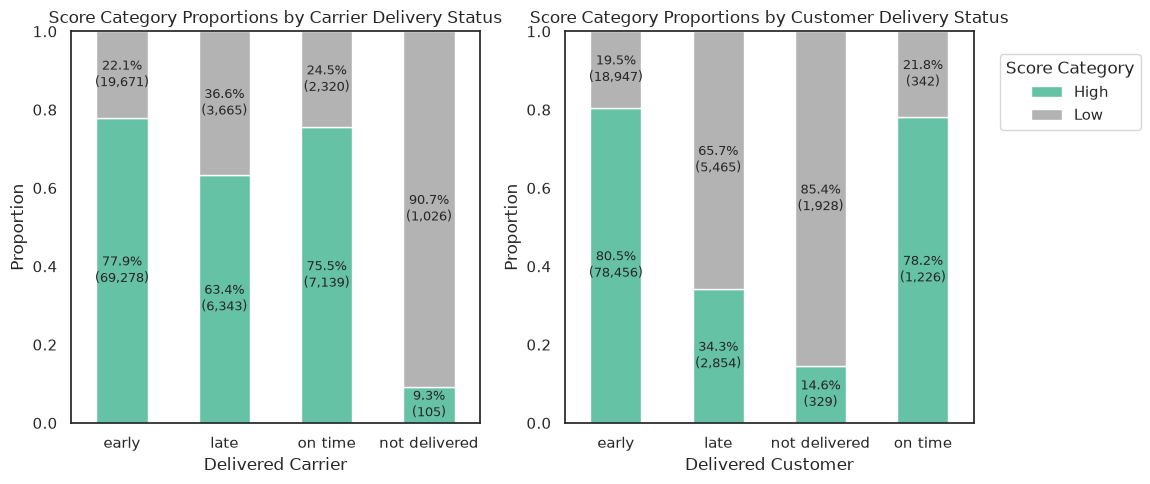

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

carrier_proportions = plot_categorical_against_score('delivered_carrier', 0)
carr_labels = format_labels(carrier_proportions.index.tolist())
axes[0].set_title(f"Score Category Proportions by Carrier Delivery Status")
axes[0].set_xticklabels(carr_labels, rotation=0, ha='center')
axes[0].set_xticks(range(len(carrier_proportions.index)))

customer_proportions = plot_categorical_against_score('delivered_customer', 1)
cust_labels = format_labels(customer_proportions.index.tolist())
axes[1].set_title(f"Score Category Proportions by Customer Delivery Status")
axes[1].set_xticklabels(cust_labels, rotation=0, ha='center')
axes[1].set_xticks(range(len(customer_proportions.index)))

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Score Category",
    loc="center left",
    bbox_to_anchor=(1.0, 0.8)
)

plt.tight_layout()
plt.show()


## State against High/Low

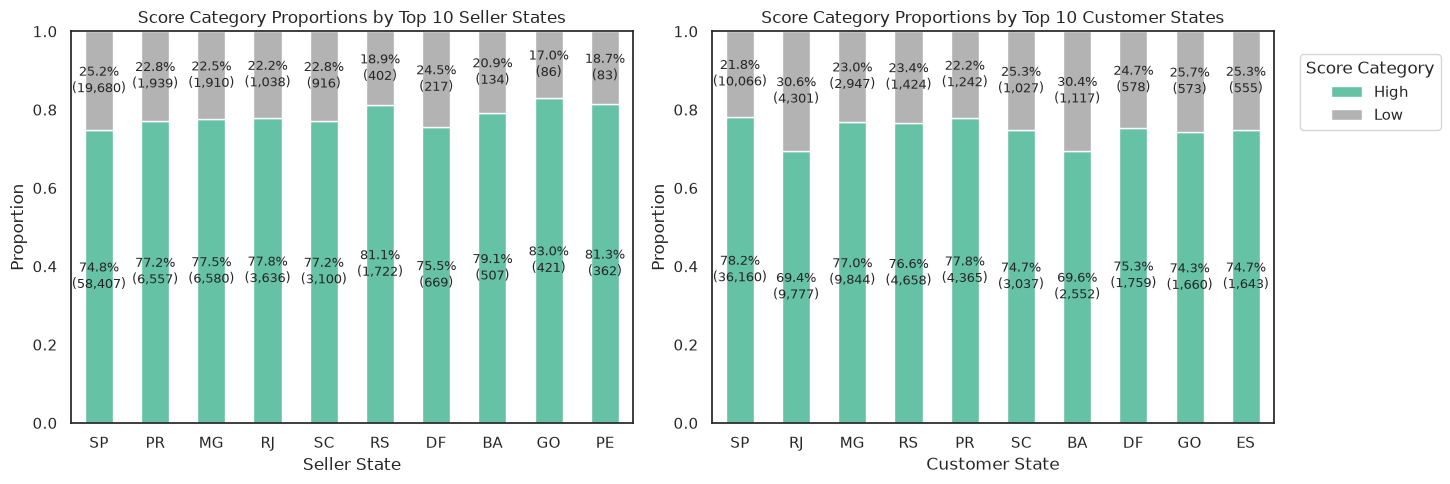

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seller_proportions = plot_categorical_against_score('seller_state', 0)
seller_labels = format_labels(seller_proportions.index.tolist())
axes[0].set_title(f"Score Category Proportions by Top 10 Seller States")
axes[0].set_xticklabels(seller_labels, rotation=0, ha='center')
axes[0].set_xticks(range(len(seller_proportions.index)))

customer_proportions = plot_categorical_against_score('customer_state', 1)
cust_labels = format_labels(customer_proportions.index.tolist())
axes[1].set_title(f"Score Category Proportions by Top 10 Customer States")
axes[1].set_xticklabels(cust_labels, rotation=0, ha='center')
axes[1].set_xticks(range(len(customer_proportions.index)))

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Score Category",
    loc="center left",
    bbox_to_anchor=(1.0, 0.8)
)

plt.tight_layout()
plt.show()


## Order Status by High/Low

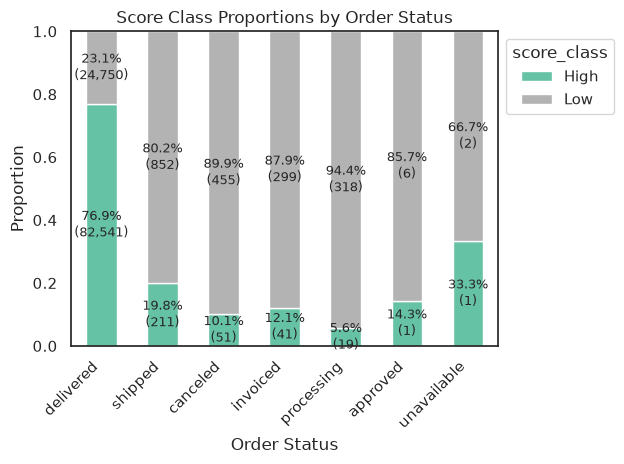

In [20]:
proportions = pd.crosstab(
    df['order_status'],
    df["score_class"],
    normalize="index"
).loc[df['order_status'].value_counts().index]


counts = pd.crosstab(
    df['order_status'],
    df["score_class"]
 ).reindex(
    index=proportions.index,
    columns=proportions.columns,
    fill_value=0
)

ax = proportions.plot(
        kind="bar",
        stacked=True,
        colormap="Set2",
        legend="Score Class"
    )

for container, category in zip(ax.containers, proportions.columns):
    for patch, percentage, count in zip(
        container,
        proportions[category],
        counts[category]
    ):
        if percentage > 0.03:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_y() + patch.get_height() / 2,
                f"{percentage:.1%}\n({count:,})",
                ha="center",
                va="center",
                fontsize=9
            )
labels = format_labels(df['order_status'].unique())
title = format_labels(['order_status'])[0].title()

ax.set_xlabel(title)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.set_title(f"Score Class Proportions by {title}")
ax.set_xticklabels(labels=labels, rotation=45, ha='right', rotation_mode='xtick')
ax.set_xticks(range(len(proportions.index)))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()


## Payment type by High/Low

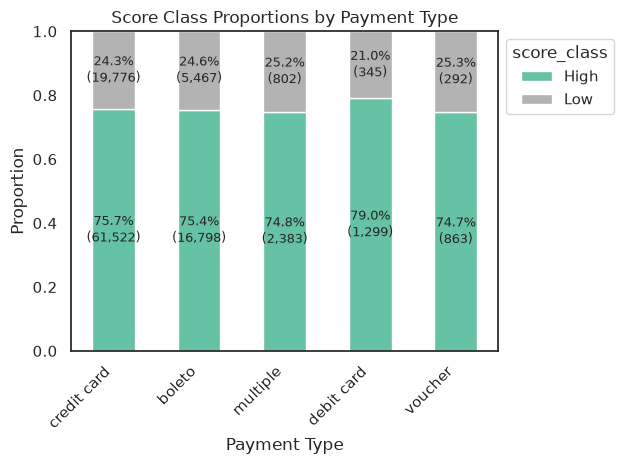

In [21]:
proportions = pd.crosstab(
    df['payment_type_all'],
    df["score_class"],
    normalize="index"
).loc[df['payment_type_all'].value_counts().index]


counts = pd.crosstab(
    df['payment_type_all'],
    df["score_class"]
 ).reindex(
    index=proportions.index,
    columns=proportions.columns,
    fill_value=0
)

ax = proportions.plot(
        kind="bar",
        stacked=True,
        colormap="Set2",
        legend="Score Class"
    )

for container, category in zip(ax.containers, proportions.columns):
    for patch, percentage, count in zip(
        container,
        proportions[category],
        counts[category]
    ):
        if percentage > 0.03:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_y() + patch.get_height() / 2,
                f"{percentage:.1%}\n({count:,})",
                ha="center",
                va="center",
                fontsize=9
            )
labels = format_labels(df['payment_type_all'].unique())

ax.set_xlabel("Payment Type")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
ax.set_title(f"Score Class Proportions by Payment Type")
ax.set_xticklabels(labels=labels, rotation=45, ha='right', rotation_mode='xtick')
ax.set_xticks(range(len(proportions.index)))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()


## Product Category by High/Low

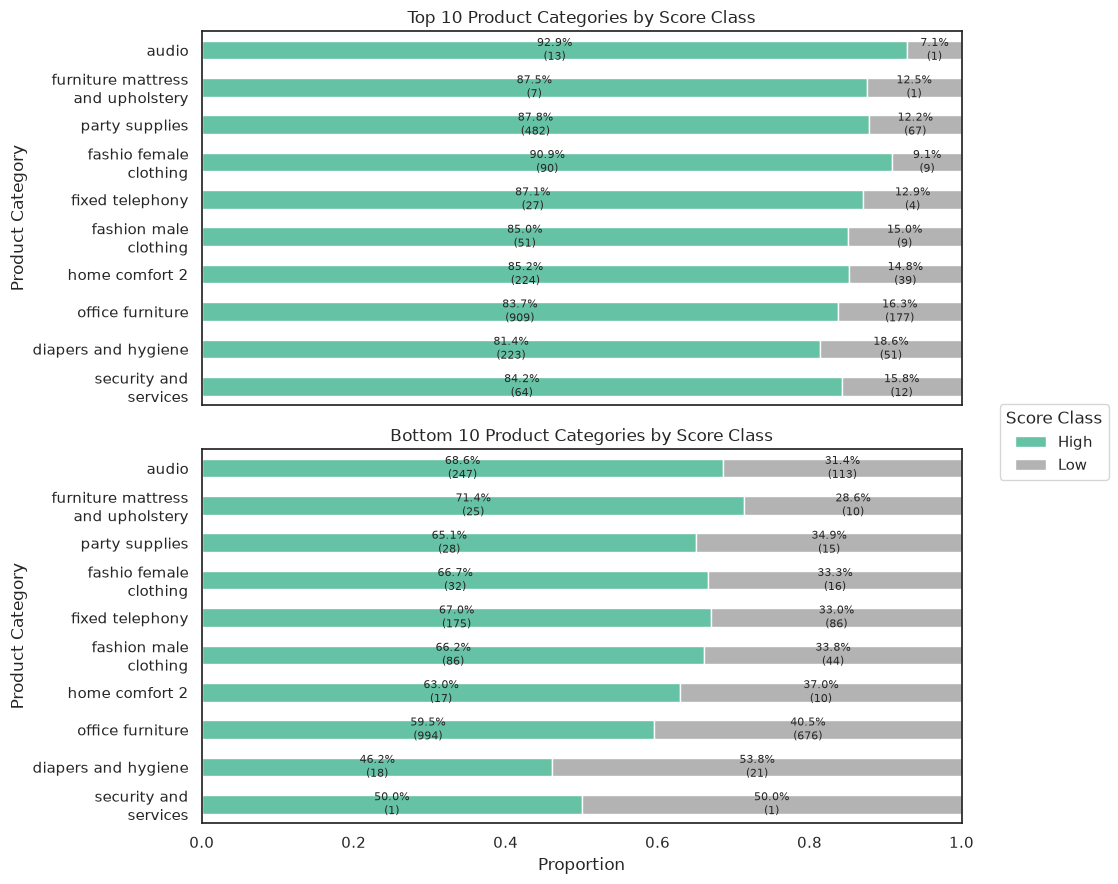

In [22]:
category_scores = (
    df.groupby("product_category_name_english")["review_score"]
    .mean()
    .dropna()
)

top10 = category_scores.nlargest(10).sort_values()
bottom10 = category_scores.nsmallest(10).sort_values()

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 9),
    sharex=True,
    sharey=True
)

for ax, data, title in zip(
    axes,
    [top10, bottom10],
    ["Top 10 Product Categories", "Bottom 10 Product Categories"]
):
    categories = data.index.tolist()

    proportions = pd.crosstab(
        df["product_category_name_english"],
        df["score_class"],
        normalize="index"
    ).reindex(categories)

    counts = pd.crosstab(
        df["product_category_name_english"],
        df["score_class"]
    ).reindex(
        index=categories,
        columns=proportions.columns,
        fill_value=0
    )

    proportions.plot(
        kind="barh",
        stacked=True,
        colormap="Set2",
        ax=ax,
        legend=False
    )

    for container, category in zip(ax.containers, proportions.columns):
        for patch, percentage, count in zip(
            container,
            proportions[category],
            counts[category]
        ):
            if percentage > 0.03:
                ax.text(
                    patch.get_x() + patch.get_width() / 2,
                    patch.get_y() + patch.get_height() / 2,
                    f"{percentage:.1%}\n({count:,})",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(
        format_labels(categories),
        ha="right"
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Proportion")
    ax.set_ylabel("Product Category")
    ax.set_title(f"{title} by Score Class")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Score Class",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

# Insights

* very high class imbalance for review scores
* customer_delivered_offset has the highest correlation score (albeit not very strong)
* correlation matrix does not show any strong indicator for the data to lean one way or another
* order_status might have some relation
* no pattern found for payment_type
* pattern found for reviews with titles/comments? (how to argue for this...)

# Feature Selection

In [23]:
remove_cols = [
    'seller_zip_code_prefix',
    'customer_zip_code_prefix',
    'payment_type_all'
    ]
df = df.drop(columns=remove_cols)
print(f'Percentage of loss from removing columns: {len(remove_cols)} ({(len(df.columns)-len(df.columns))/len(df.columns):.2%})')
df.info()

Percentage of loss from removing columns: 3 (0.00%)
<class 'pandas.DataFrame'>
RangeIndex: 109547 entries, 0 to 109546
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   price                          109547 non-null  float64
 1   freight_value                  109547 non-null  float64
 2   product_category_name          109547 non-null  str    
 3   product_name_lenght            109547 non-null  float64
 4   product_description_lenght     109547 non-null  float64
 5   product_photos_qty             109547 non-null  float64
 6   product_weight_g               109547 non-null  float64
 7   product_length_cm              109547 non-null  float64
 8   product_height_cm              109547 non-null  float64
 9   product_width_cm               109547 non-null  float64
 10  product_category_name_english  109547 non-null  str    
 11  order_status                   109547 non-null  st

# Data Model (output)

In [24]:
import os
# Save consolidated dataset

output_path = "./olist.csv"
df.to_csv(output_path, index=False)
print(f"✅ Saved consolidated dataset to: {output_path}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Size: {os.path.getsize(output_path) / 1e6:.2f} MB")

✅ Saved consolidated dataset to: ./olist.csv
   Shape: 109,547 rows × 30 columns
   Size: 22.10 MB
